# Import and Utilities

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import random
import matplotlib.pyplot as plt
import os
import time
from tqdm.auto import tqdm 

from sklearn.model_selection import train_test_split

# Assuming you saved the PyTorch model code from the previous step as 'survite.py'
from models.survite import SurvITE 
from utils.evaluation import SurvITE_Evaluator

# --- Utility Function for Batching (Replaces utils.utils.f_get_minibatch) ---
def f_get_minibatch(mb_size, x, y, t, a, w=None):
    idx = np.random.choice(np.shape(x)[0], mb_size, replace=False)
    x_mb = x[idx, :].astype(np.float32)
    y_mb = y[idx, :].astype(np.float32)
    t_mb = t[idx, :].astype(np.float32)
    a_mb = a[idx, :].astype(np.float32)
    
    if w is not None:
        w_mb = w[idx, :, :].astype(np.float32)
        return x_mb, y_mb, t_mb, a_mb, w_mb
    else:
        return x_mb, y_mb, t_mb, a_mb

# Config

In [2]:
# Settings
ipm_type      = 'wasserstein' # Options: 'wasserstein', 'mmd_lin', 'no_ipm'
weight        = False
is_smoothing  = False
is_treat      = True
is_training   = True

OUT_ITERATION = 5
N_tr = 5000
N_te = 5000

if not weight:
    weight_type = 'noweight'
else:
    weight_type  = '' 

if ipm_type == 'no_ipm':
    beta       = 0.
else:
    beta   = 1e-3 

if is_smoothing:
    gamma  = 1e-3
else:
    gamma  = 0.

lr_rate   = 1e-3
mb_size   = 512
keep_prob = 0.7 
dropout_rate = 1.0 - keep_prob # PyTorch uses dropout_rate (probability to drop)

seed           = 1234
TMAX           = 30
eval_times     = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
modelname      = 'SurvITE'

# Reproducibility
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

# Data

In [3]:
"""
x - features (in this sample, we have 10)
a - treatment indicator
t - time to event
y - event indicator
"""

try:
    npz  = np.load('./data/tr_data.npz')
    tr_x = npz['x']
    tr_a = npz['a']
    tr_t = npz['t']
    tr_y = npz['y']

    npz  = np.load('./data/te_data.npz')
    te_x = npz['x']
    te_a = npz['a']
    te_t = npz['t']
    te_y = npz['y']
    print("Loaded data from files.")
except FileNotFoundError:
    print("Data files not found. Generating dummy data...")
    
# --- Data Pre-processing ---
# Ensure shapes are correct (N, 1)
tr_y = tr_y.reshape([-1,1])
tr_t = tr_t.reshape([-1,1])
tr_a = tr_a.reshape([-1,1])

te_y = te_y.reshape([-1,1])
te_t = te_t.reshape([-1,1])
te_a = te_a.reshape([-1,1])

if not is_treat:
    tr_a = np.ones_like(tr_t)
    te_a = np.ones_like(te_t)

# Prepare weights
if is_treat:
    tr_w  = np.ones([np.shape(tr_x)[0], TMAX+1, 2])
else:
    tr_w  = np.ones([np.shape(tr_x)[0], TMAX+1, 1])

# Train/Validation Split
tr_x_, va_x, tr_y_, va_y, tr_t_, va_t, tr_a_, va_a, tr_w_, va_w = train_test_split(
    tr_x, tr_y, tr_t, tr_a, tr_w, test_size=0.2, random_state=seed
)

print(f"Train size: {tr_x_.shape}, Val size: {va_x.shape}")

Loaded data from files.
Train size: (4000, 10), Val size: (1000, 10)


In [4]:
tr_x.mean(axis=0)

array([ 0.00545732,  0.00803578,  0.01589106,  0.0136872 ,  0.01848133,
       -0.01213854,  0.01924723, -0.00076494, -0.01117209, -0.00054947])

In [5]:
tr_x.std(axis=0)

array([1.01290298, 1.00633771, 1.00484917, 0.9949024 , 1.00657694,
       1.00053393, 0.98399336, 1.01218566, 1.00872341, 1.00566782])

# Model

In [6]:
# Network Parameters
num_Event   = 1
z_dim       = 100
x_dim       = np.shape(tr_x)[1]
num_layers1 = 3
h_dim1      = 100
num_layers2 = 2
h_dim2      = 100

input_dims = {
    'x_dim': x_dim,
    'num_Event': num_Event,
    't_max': TMAX+1
}

network_settings = {
    'z_dim': z_dim,     
    'h_dim1': h_dim1, 
    'num_layers1': num_layers1, 
    'h_dim2': h_dim2, 
    'num_layers2': num_layers2,
    'active_fn': 'elu', # Passing string identifier
    'reg_scale': 0.,
    'ipm_term' : ipm_type, 
    'is_treat' : is_treat,
    'is_smoothing': is_smoothing
}

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize Model
model = SurvITE(input_dims, network_settings, device=device)

# Initialize Optimizer (PyTorch requires this external to the model usually)
optimizer = optim.Adam(model.parameters(), lr=lr_rate)

# Directory for saving
savepath = './{}/surviTE/'.format(modelname)
if not os.path.exists(savepath):
    os.makedirs(savepath)

Using device: cpu


# Train

In [7]:
iterations = 5000 # Reduced for tutorial speed, set back to 20000 for full train

avg_tr_loss_total = 0.
avg_tr_loss       = 0.
avg_tr_loss_ipm   = 0.

avg_va_loss_total = 0.
avg_va_loss       = 0.
avg_va_loss_ipm   = 0.

check_step        = 100
min_loss          = 1e+8
max_flag          = 20
stop_flag         = 0

print("Start Training...")

if is_training:
    pbar = tqdm(range(iterations), desc="Training", unit="step")

    for itr in pbar:
        
        # --- Training Step ---
        if beta == 0.:
            # Baseline training (no IPM)
            x_mb, y_mb, t_mb, a_mb = f_get_minibatch(mb_size, tr_x_, tr_y_, tr_t_, tr_a_)    
            tmp_tr_loss_total, tmp_tr_loss, _ = model.train_baseline(
                optimizer, x_mb, y_mb, t_mb, a_mb, dropout_rate=dropout_rate
            )
            tmp_tr_loss_ipm = 0.
        else:
            # Full training
            x_mb, y_mb, t_mb, a_mb, w_mb = f_get_minibatch(mb_size, tr_x_, tr_y_, tr_t_, tr_a_, tr_w_)
            tmp_tr_loss_total, tmp_tr_loss, tmp_tr_loss_ipm = model.train_step(
                optimizer, x_mb, y_mb, t_mb, a_mb, w_mb, 
                beta=beta, gamma=gamma, dropout_rate=dropout_rate
            )

        avg_tr_loss_total += tmp_tr_loss_total / check_step
        avg_tr_loss       += tmp_tr_loss / check_step
        avg_tr_loss_ipm   += tmp_tr_loss_ipm / check_step

        # --- Validation Step ---
        # We process validation in one batch (or loop if too large, here assuming fits in memory)
        # Note: We use calculate_loss directly with dropout_rate=0.0 (eval mode implicit in get_loss logic)
        
        # Sample validation batch (or use full validation set if small enough)
        curr_va_size = min(mb_size, np.shape(va_x)[0])
        if beta == 0:
             x_mb, y_mb, t_mb, a_mb = f_get_minibatch(curr_va_size, va_x, va_y, va_t, va_a)
             # Create dummy weights for interface consistency
             w_dummy = np.ones([curr_va_size, TMAX+1, 2])
             model.eval()
             with torch.no_grad():
                 # Using internal method to calculate loss without backprop
                 x_t = torch.tensor(x_mb).float().to(device)
                 y_t = torch.tensor(y_mb).float().to(device)
                 t_t = torch.tensor(t_mb).float().to(device)
                 a_t = torch.tensor(a_mb).float().to(device)
                 w_t = torch.tensor(w_dummy).float().to(device)
                 
                 v_loss, v_fact, v_ipm = model.calculate_loss(x_t, y_t, t_t, a_t, w_t, beta=0., gamma=0.)
                 tmp_va_loss_total = v_loss.item()
                 tmp_va_loss = v_fact.item()
                 tmp_va_loss_ipm = 0.
        else:
            x_mb, y_mb, t_mb, a_mb, w_mb = f_get_minibatch(curr_va_size, va_x, va_y, va_t, va_a, va_w)
            model.eval()
            with torch.no_grad():
                 x_t = torch.tensor(x_mb).float().to(device)
                 y_t = torch.tensor(y_mb).float().to(device)
                 t_t = torch.tensor(t_mb).float().to(device)
                 a_t = torch.tensor(a_mb).float().to(device)
                 w_t = torch.tensor(w_mb).float().to(device)
                 
                 v_loss, v_fact, v_ipm = model.calculate_loss(x_t, y_t, t_t, a_t, w_t, beta=beta, gamma=gamma)
                 tmp_va_loss_total = v_loss.item()
                 tmp_va_loss = v_fact.item()
                 tmp_va_loss_ipm = v_ipm.item()

        avg_va_loss_total += tmp_va_loss_total / check_step
        avg_va_loss       += tmp_va_loss / check_step
        avg_va_loss_ipm   += tmp_va_loss_ipm / check_step

        # --- Logging and Saving ---
        if (itr + 1) % check_step == 0:
            stop_flag += 1
            
            print("ITR {:04d} | TR: loss_T={:.3f} loss_S={:.3f} loss_IPM={:.3f} | VA: loss_T={:.3f} loss_S={:.3f} loss_IPM={:.3f}".format(
                itr+1, avg_tr_loss_total, avg_tr_loss, avg_tr_loss_ipm, avg_va_loss_total, avg_va_loss, avg_va_loss_ipm)
            )

            # Early Stopping Check
            if min_loss > avg_va_loss_total:
                min_loss = avg_va_loss_total
                stop_flag = 0
                
                # Save PyTorch Model State
                model_path = os.path.join(savepath, 'model_{}{}.pt'.format(ipm_type, weight_type))
                torch.save(model.state_dict(), model_path)
                pbar.write(f"Step {itr+1}: Model saved! New Best Val Loss: {min_loss:.4f}")
            
            else:
                if stop_flag >= max_flag:
                    pbar.write(f"Step {itr+1}: Early stopping triggered.")
                    break

            # Reset Accumulators
            avg_tr_loss_total, avg_tr_loss, avg_tr_loss_ipm = 0., 0., 0.
            avg_va_loss_total, avg_va_loss, avg_va_loss_ipm = 0., 0., 0.

Start Training...
ITR 0100 | TR: loss_T=11.447 loss_S=11.286 loss_IPM=160.903 | VA: loss_T=12.291 loss_S=12.138 loss_IPM=152.869
Model saved...
ITR 0200 | TR: loss_T=6.201 loss_S=6.060 loss_IPM=140.231 | VA: loss_T=6.074 loss_S=5.925 loss_IPM=149.366
Model saved...
ITR 0300 | TR: loss_T=5.831 loss_S=5.701 loss_IPM=129.837 | VA: loss_T=6.008 loss_S=5.871 loss_IPM=137.144
Model saved...
ITR 0400 | TR: loss_T=5.585 loss_S=5.462 loss_IPM=122.850 | VA: loss_T=5.911 loss_S=5.781 loss_IPM=129.618
Model saved...
ITR 0500 | TR: loss_T=5.487 loss_S=5.368 loss_IPM=119.601 | VA: loss_T=5.930 loss_S=5.808 loss_IPM=122.158
ITR 0600 | TR: loss_T=5.341 loss_S=5.228 loss_IPM=113.487 | VA: loss_T=5.959 loss_S=5.841 loss_IPM=118.791
ITR 0700 | TR: loss_T=5.187 loss_S=5.076 loss_IPM=110.068 | VA: loss_T=6.004 loss_S=5.890 loss_IPM=114.888
ITR 0800 | TR: loss_T=5.070 loss_S=4.961 loss_IPM=108.563 | VA: loss_T=6.087 loss_S=5.974 loss_IPM=113.517
ITR 0900 | TR: loss_T=4.978 loss_S=4.869 loss_IPM=109.129 | VA

# Inference

In [8]:
# Restore Best Model
model_path = os.path.join(savepath, 'model_{}{}.pt'.format(ipm_type, weight_type))
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print("Model restored from", model_path)
else:
    print("Model file not found. Using current weights.")

model.eval() # Set to evaluation mode

# Predict
surv1 = model.predict_survival_A1(te_x)
surv0 = model.predict_survival_A0(te_x)

hzrd1 = model.predict_hazard_A1(te_x)
hzrd0 = model.predict_hazard_A0(te_x)

# Combine based on treatment assignment (for factual analysis)
hzrd = np.zeros_like(hzrd1)
surv = np.zeros_like(surv1)

if is_treat:
    # Where A=0
    mask0 = (te_a[:, 0] == 0)
    hzrd[mask0, :] = hzrd0[mask0, :]
    surv[mask0, :] = surv0[mask0, :]
    
    # Where A=1
    mask1 = (te_a[:, 0] == 1)
    hzrd[mask1, :] = hzrd1[mask1, :]
    surv[mask1, :] = surv1[mask1, :]
else:
    # If not treated setup, usually defaults to A=1 logic or generic
    hzrd = hzrd1
    surv = surv1

print("Survival Probability Shape:", surv.shape)
print("Sample Survival Probabilities (First 5 patients, first 5 times):")
print(surv[:5, :5])

Model restored from ./SurvITE/surviTE/model_wassersteinnoweight.pt
Survival Probability Shape: (5000, 31)
Sample Survival Probabilities (First 5 patients, first 5 times):
[[0.9999006  0.98279804 0.95854855 0.9406115  0.93447644]
 [0.9999969  0.9966251  0.99423397 0.9801905  0.97149104]
 [0.9999494  0.99630755 0.9918248  0.98782915 0.9764665 ]
 [0.9997603  0.9591783  0.9404873  0.9238089  0.89614964]
 [0.9998725  0.9737995  0.95823956 0.88949853 0.8694058 ]]


In [9]:
surv[0]

array([0.9999006 , 0.98279804, 0.95854855, 0.9406115 , 0.93447644,
       0.91455555, 0.903585  , 0.88669765, 0.86310333, 0.84476143,
       0.8370537 , 0.7467086 , 0.62956583, 0.5944226 , 0.5424496 ,
       0.49688804, 0.389226  , 0.3529085 , 0.282497  , 0.2522226 ,
       0.19528656, 0.18108062, 0.17350513, 0.1723071 , 0.13773751,
       0.0910411 , 0.07388217, 0.07131399, 0.02737933, 0.02478416,
       0.02418033], dtype=float32)

In [10]:
surv0.shape

(5000, 31)

# Evaluation

In [11]:
tr_t.max()

np.float64(30.0)

C-index (IPCW) at median time: 0.7126
C-index (IPCW) at t=5: 0.6319
C-index (IPCW) at t=10: 0.6374
C-index (IPCW) at t=15: 0.6694
C-index (IPCW) at t=20: 0.7087
C-index (IPCW) at t=25: 0.7257
Integrated Brier Score (IBS): 0.1243


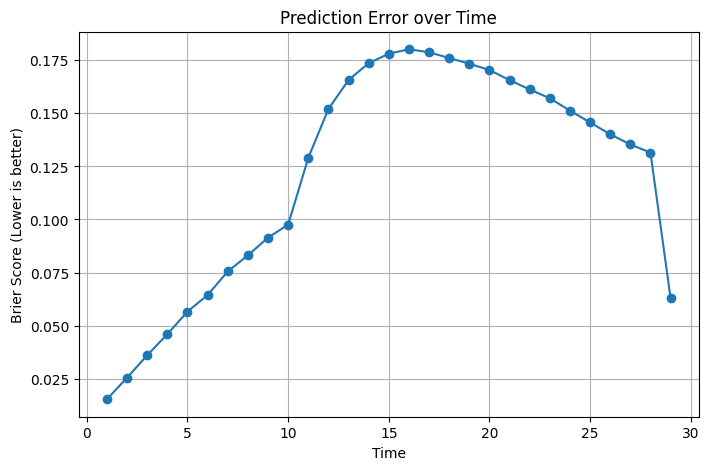

In [14]:
# --- 1. Prepare Data for Evaluator ---
# The evaluator needs raw numpy arrays
train_data = (tr_x, tr_y, np.clip(tr_t, 1, 29), tr_a)
test_data  = (te_x, te_y, te_t, te_a)

# --- 2. Initialize Evaluator ---
evaluator = SurvITE_Evaluator(model, train_data, test_data)

# --- 3. Compute C-Index ---
# Compute at specific times, e.g., median time or specific horizons
c_index_med = evaluator.calculate_c_index()
print(f"C-index (IPCW) at median time: {c_index_med:.4f}")

# You can also check C-index at t=[5, 10, 15, 20]
c_index_5, c_index_10, c_index_15, c_index_20, c_index_25 = (evaluator.calculate_c_index(eval_time=5), 
                                                evaluator.calculate_c_index(eval_time=10),
                                                evaluator.calculate_c_index(eval_time=15),
                                                evaluator.calculate_c_index(eval_time=20),
                                                evaluator.calculate_c_index(eval_time=25))
print(f"C-index (IPCW) at t=5: {c_index_5:.4f}")
print(f"C-index (IPCW) at t=10: {c_index_10:.4f}")
print(f"C-index (IPCW) at t=15: {c_index_15:.4f}")
print(f"C-index (IPCW) at t=20: {c_index_20:.4f}")
print(f"C-index (IPCW) at t=25: {c_index_25:.4f}")

# --- 4. Compute Integrated Brier Score ---
ibs_score, times, bs_scores = evaluator.calculate_ibs()
print(f"Integrated Brier Score (IBS): {ibs_score:.4f}")

# --- 5. Plot Brier Score over Time ---
plt.figure(figsize=(8, 5))
plt.plot(times, bs_scores, marker='o')
plt.xlabel("Time")
plt.ylabel("Brier Score (Lower is better)")
plt.title("Prediction Error over Time")
plt.grid(True)
plt.show()